In [1]:
using Pkg
Pkg.activate("..")   # activate project environment

using Plots
using LaTeXStrings
using DataFrames
using GLM # for linear regression

using Revise # automatically sync src updates ----> suuuuuper important for development
using SkyrmionTunneling
const ST = SkyrmionTunneling # alias for easier referencing

  Activating project at `~/Documents/GitHub/skyrmion-tunnelling`
[ Info: Precompiling SkyrmionTunneling [51d433a5-d9a2-4638-a6de-06b0503db32e] (cache misses: include_dependency fsize change (2), wrong source (2))


SkyrmionTunneling

# Skyrmion collapse

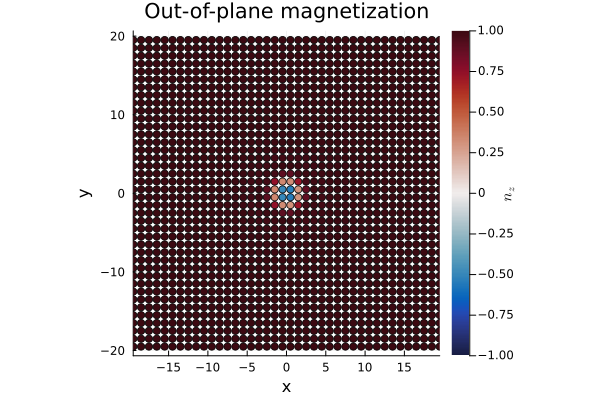

total charge Q = 0.6136586760971212

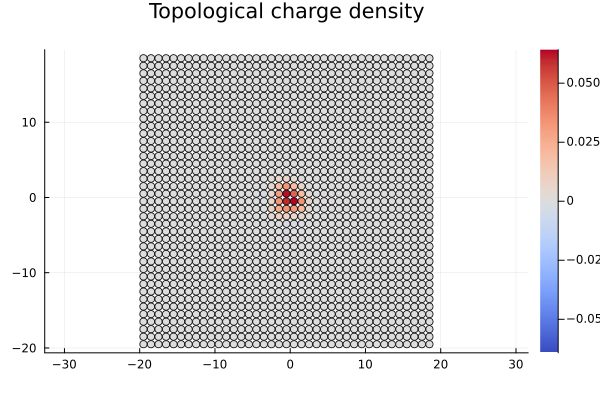

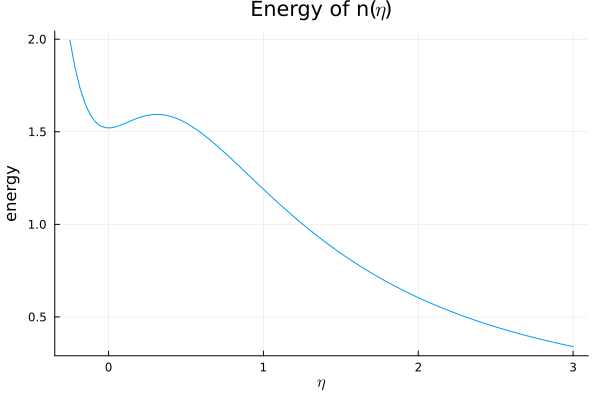

Imaginary part = 3.557153238242702e-5
WARNING ----> imaginary part is nonzero !!!!! ---------> It gets neglected via a real projection


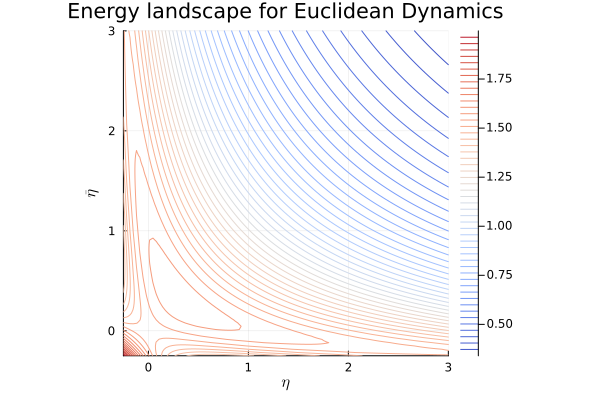

The saddle point is at -0.00038081360172874726 + 2.9677018034420742e-5im
The instantonic trajectory passes through the point 
 x = 0.04848159158503326

Progress:   1%|▌                                        |  ETA: 0:00:08

 + 1.69613635272543e-5im
 y = -0.011002157463046567 - 2.770701478274189e-5im
sanity check : |H_inst-H0| = 5.911963945433598e-12
-- Integrating forwards -- 


Progress: 100%|█████████████████████████████████████████| Time: 0:00:06
Progress:   1%|▍                                        |  ETA: 0:00:13

-- Integrating backwards -- 


Progress: 100%|█████████████████████████████████████████| Time: 0:00:13


imaginary = 0.0020016853335281183


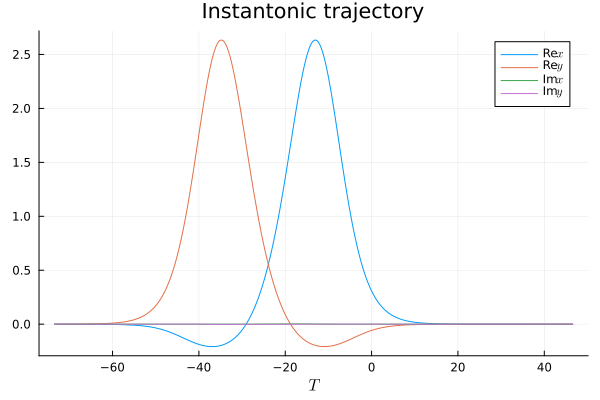

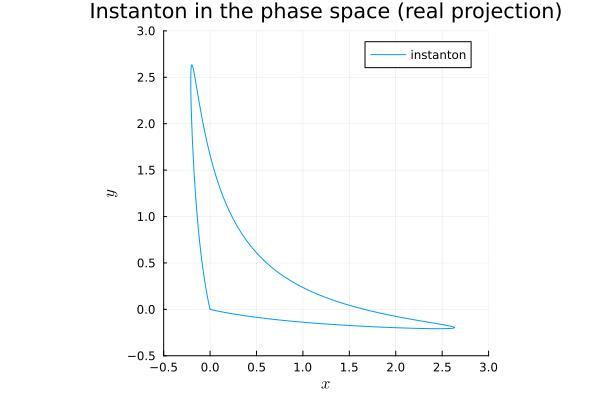

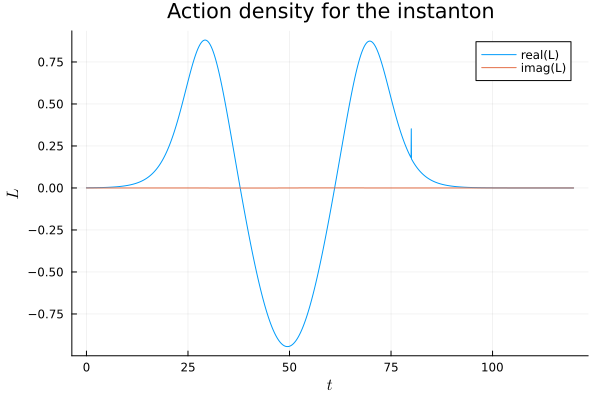


Total action = 7.596638373734223 - 2.6153652620479127e-5im


(7.596638373734223 - 2.6153652620479127e-5im, ComplexF64[-0.0004265035706737922 + 3.0768640349223835e-5im -0.00042716895744574065 + 3.076843422543371e-5im … -0.00037956800275168673 + 3.077015034827169e-5im -0.00037956308309554967 + 3.076997245975967e-5im; -0.0001771546015278034 - 3.072333854224942e-5im -0.00017418611420622006 - 3.072247404682042e-5im … -0.0003845257283277511 - 3.072749373488286e-5im -0.00038457636094998157 - 3.072669111744226e-5im])

In [32]:
lattice = SquareLattice(40,40)
J1 = 1.0;	J2 = -0.3;	J3 = -0.2
K = 0.02
B_avg = 0.22;	B = ST.uniform_B(B_avg,lattice)

params = HamiltonianParameters(J1,J2,J3,K,B)
boundary = PeriodicBoundary()
system = System(params,lattice,boundary)

n_Sk = ST.skyrmion(system, annealing=true, LLG_relax=false, show_result=true, N_steps=10000)
coord = LambdaCoordinate(ST.w_project(n_Sk))

up, vp = ST.uv(n_Sk)
um, vm = ST.uv(ST.ferromagnetic(lattice))

coord = EtaCoordinate(up,um,vp,vm)
ST.show_double_well(system, coord,xmin=-0.25, xmax=3.0)
savefig("FM_inst.png")
ST.show_energy_contours(system, coord,xmin=-0.25, xmax=3.0, N_points=100,levels = 50)
savefig("")

S_inst, sol = ST.instanton(system,coord, x_init = 0.0, direction_guess=[0.05, 0.00], T_backward=80.0, T_forward=40.0, dt=0.05, show_action=true, xlims=(-0.5,3))

# Reproducing Diaz's results

TriangularLattice(30, 30)
PeriodicBoundary()
Hamiltonian parameters:
J1 = 1.0	J2 = -0.5	J3 = 0.0
K = 0.15
B_avg = 0.17	B_uniform = true



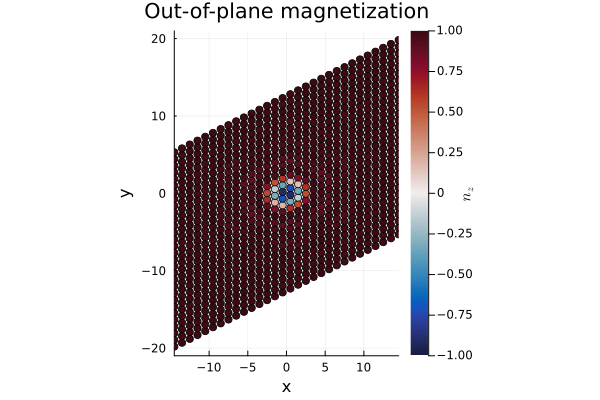

total charge Q = 0.7771249011636188

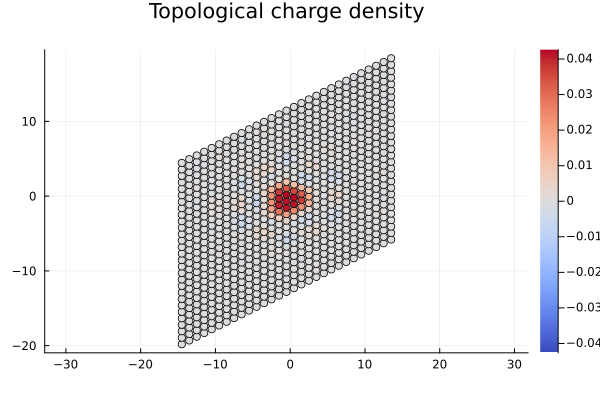

Energy = -1.4023619322492777


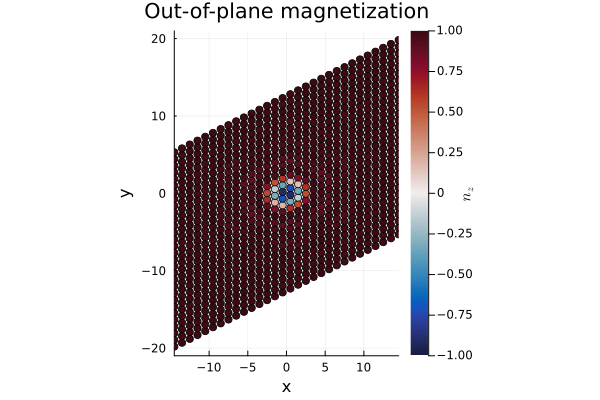

In [84]:
lattice = TriangularLattice(30,30)
J1 = 1.0; J2 = -0.5; J3 = 0.0
K = 0.15
#B = ST.local_B_field(lattice, B_centre=0.20, B_inf=0.2, radius=1.0, relax_length=2.0)
B = ST.uniform_B(0.17,lattice)
params = HamiltonianParameters(J1,J2,J3,K,B)
boundary = PeriodicBoundary()

system1 = System(params,lattice,boundary)
ST.describe_system(system1)
n_Sk = ST.skyrmion(system1, LLG_relax=false)
println("Energy = ", ST.H(n_Sk,system1))
ST.show_nz(n_Sk,lattice)

In [85]:
minimum(n_Sk)

-0.9579532648427267

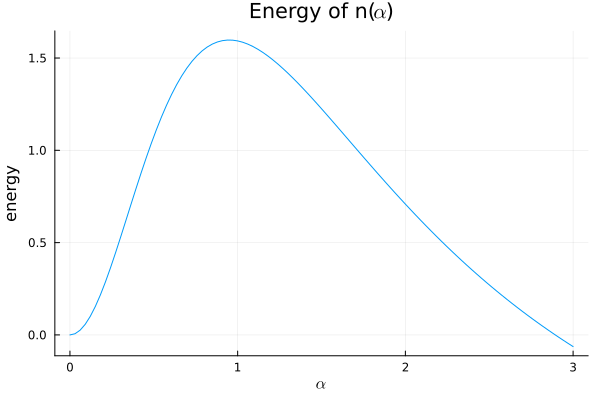

Imaginary part = 0.00024954409662142113
WARNING ----> imaginary part is nonzero !!!!! ---------> It gets neglected via a real projection


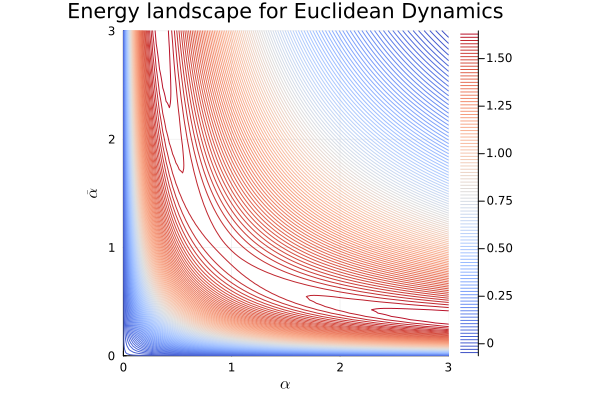

Imaginary part = 0.001513219100710892
WARNING ----> imaginary part is nonzero !!!!! ---------> It gets neglected via a real projection


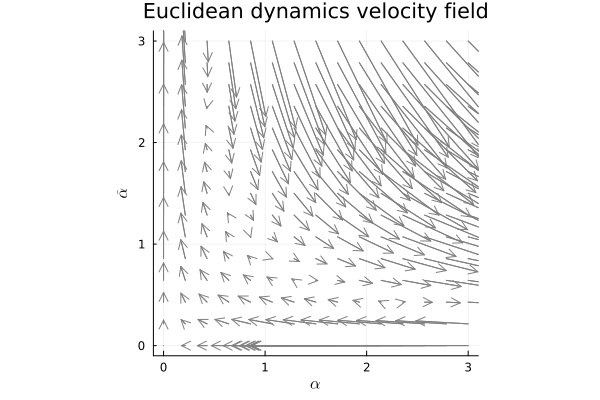

In [86]:
u,v = ST.uv(ST.rotate_around_z(n_Sk, 1.0))
up, vp = ST.uv(ST.ferromagnetic(lattice))
coord = AlphaCoordinate(u,v)
#coord = EtaCoordinate(up,u,vp,v)
ST.describe_collective_coordinate(system1,coord,xmin=0.0, xmax=3.0, N_points = 100, levels=100)

The saddle point is at 0.0 + 0.0im
The instantonic trajectory passes through the point 
 x = 0.049999999999999635 + 8.29868948354576e-9im
 y = 0.049999999999999635 - 8.29868948354576e-9im
sanity check : |H_inst-H0| = 0.017520907153993903
-- Integrating forwards -- 


Progress: 100%|█████████████████████████████████████████| Time: 0:00:03


-- Integrating backwards -- 


Progress: 100%|█████████████████████████████████████████| Time: 0:00:03


imaginary = 0.01433457670557346


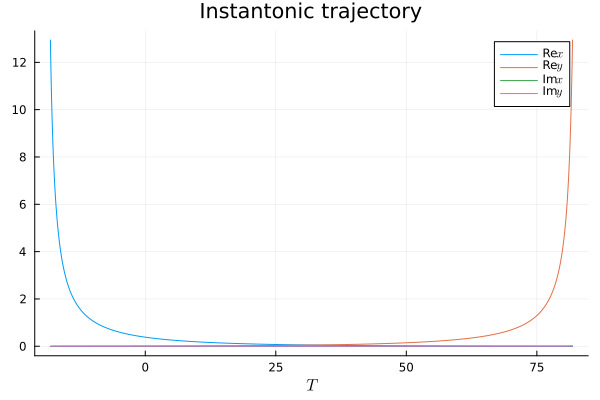

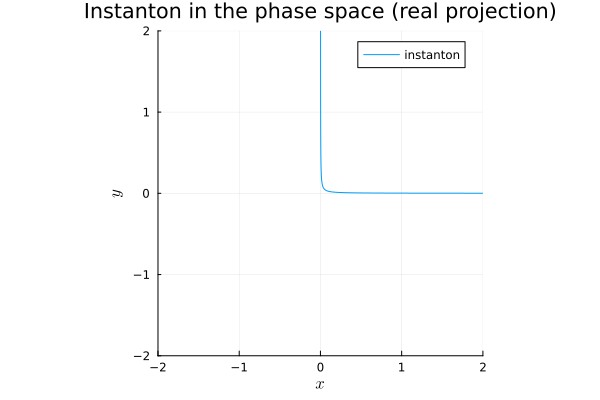

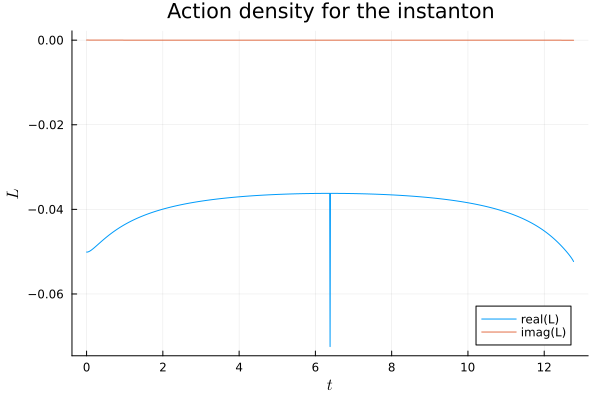


Total action = -0.5047656449560181 - 3.1541329510244777e-7im


(-0.5047656449560181 - 3.1541329510244777e-7im, ComplexF64[12.94151811040181 - 0.01433457670557346im 11.955440069277511 - 0.011822723637125266im … 0.0005620971891574485 - 4.6986400065219033e-7im 0.0005492408439963207 - 4.7613704864960546e-7im; 0.0005492408439963207 + 4.7613704864960546e-7im 0.0005620971891574485 + 4.6986400065219033e-7im … 11.955440069277511 + 0.011822723637125266im 12.94151811040181 + 0.01433457670557346im])

In [88]:
S_inst, sol = ST.instanton(system1,coord, x_init = 0.0, direction_guess=[0.05, 0.05], T_backward=50.0, T_forward=50.0, dt=0.01, show_action=true)

Progress: 100%|█████████████████████████████████████████| Time: 0:00:01


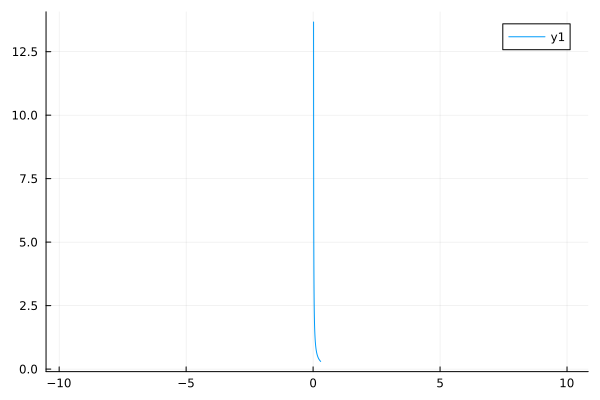

In [92]:
x0 = 0.3
sol = real.(ST.solve_ivp([x0, x0], system1, coord, dt=0.01, T = 500))
plot(sol[1,:], sol[2,:], aspect_ratio=:equal)